In [1]:
import requests
from pathlib import Path
r = requests.get(
    "https://cdn.lazarev.fun/data/"
    "const_vdv_pretty_with_mw_volume.tsv"
)
Path("const_vdv_pretty_with_mw_volume.tsv") \
    .write_text(r.content.decode("utf-8"))

1541

In [3]:
import pandas as pd
df = pd.read_csv(
    "const_vdv_pretty_with_mw_volume.tsv",
    sep="\t"
)
df.head()

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume
0,Азот,N2,0.1370,38.7,28.014,2.998428
1,Аммиак,NH3,0.4225,37.1,17.031,1.873579
2,Аргон,Ar,0.1355,32.0,39.900,4.988916
3,Ацетилен,C2H2,0.4516,52.2,26.040,3.001687
4,Бром,Br2,0.9750,59.1,159.810,14.476459


In [4]:
%pip install scikit-learn

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
reg = LinearRegression()
reg.fit(df[["Volume", "Const_a"]], df["Mol_weight"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
df["Mol_weight_pred"] = \
    df[["Volume", "Const_a"]]\
    .apply(
        lambda x: sum(x * reg.coef_) + reg.intercept_,
        axis=1
    )

In [19]:
reg.coef_

array([11.13579893, -6.80865512])

<Axes: xlabel='Volume', ylabel='Mol_weight'>

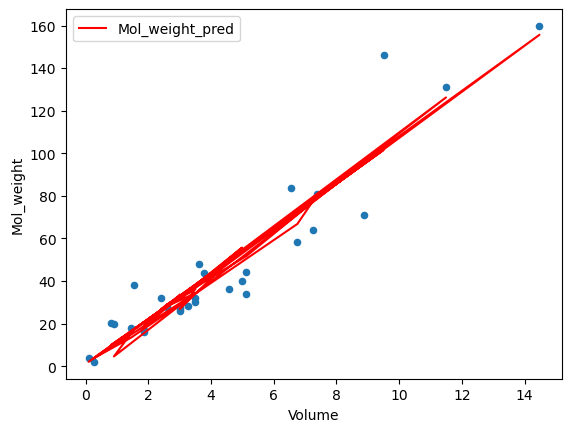

In [22]:
import matplotlib.pyplot as plt
_, ax = plt.subplots()
df.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df.plot(
    x="Volume", y="Mol_weight_pred", kind="line", ax=ax, color="red"
) 

In [20]:
df_volume_sorted = df.sort_values(by="Volume")

<Axes: xlabel='Volume', ylabel='Mol_weight'>

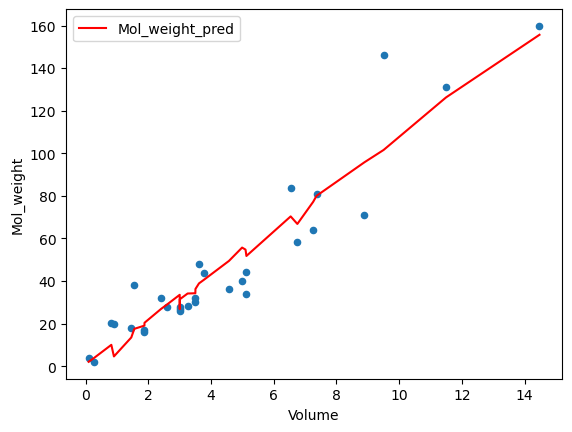

In [21]:
_, ax = plt.subplots()
df_volume_sorted.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df_volume_sorted.plot(
    x="Volume", y="Mol_weight_pred", color="red", ax=ax
) 

<Axes: xlabel='Volume', ylabel='Mol_weight'>

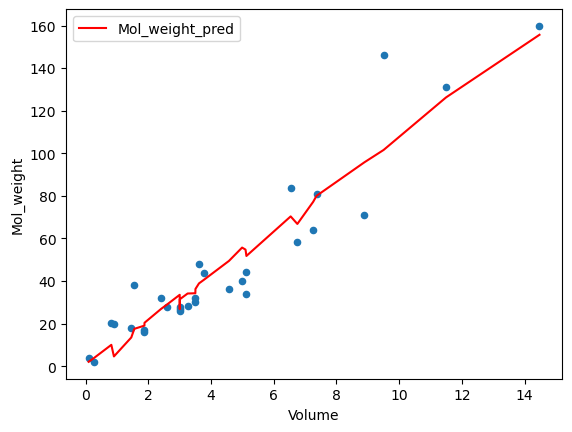

In [23]:
df_volume_a_sorted = df.sort_values(by=["Volume", "Const_a"])
_, ax = plt.subplots()
df_volume_a_sorted.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df_volume_a_sorted.plot(
    x="Volume", y="Mol_weight_pred", color="red", ax=ax
)

In [ ]:
df_volume_a_sorted = df.sort_values(by=["Volume", "Const_a"])
_, ax = plt.subplots()
df_volume_a_sorted.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df_volume_a_sorted.plot(
    x="Volume", y="Mol_weight_pred", color="red", ax=ax
)

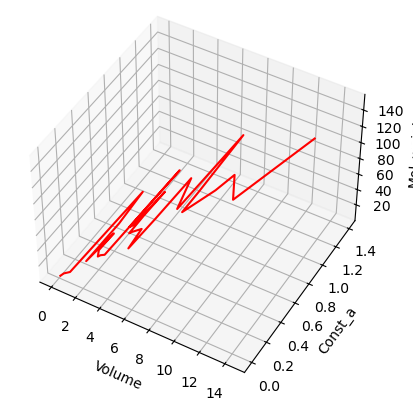

In [37]:
df_volume_a_sorted = \
df.sort_values(by=["Volume", "Const_a"])

_, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot(
    df_volume_a_sorted["Volume"], 
    df_volume_a_sorted["Const_a"], 
    df_volume_a_sorted["Mol_weight_pred"],
    "r"
)
ax.set_xlabel("Volume")
ax.set_ylabel("Const_a")
ax.set_zlabel("Mol_weight")
ax.view_init(45)

In [38]:
from sklearn.metrics import r2_score

In [39]:
r2_score(df["Mol_weight"], df["Mol_weight_pred"])

0.8859390731580069

In [41]:
reg.score(df[["Volume", "Const_a"]], df["Mol_weight"])

0.8859390731580069

In [53]:
from itertools import combinations, chain
columns_list = ["Volume", "Const_a", "Const_b"]
features_list = list(chain.from_iterable(
    combinations(columns_list, r) 
    for r in range(1, len(columns_list) + 1)
))
for features in features_list:
    features = list(features)
    reg = LinearRegression()
    reg.fit(df[features], df["Mol_weight"])
    print(
        reg.score(df[features], df["Mol_weight"]),
        features
    )

0.8829642018987853 ['Volume']
0.14512074592799862 ['Const_a']
0.08481041094961972 ['Const_b']
0.8859390731580069 ['Volume', 'Const_a']
0.8848418269668347 ['Volume', 'Const_b']
0.14767334002883536 ['Const_a', 'Const_b']
0.885941742278923 ['Volume', 'Const_a', 'Const_b']


In [54]:
%pip install mendeleev

In [59]:
import mendeleev
elem_F = mendeleev.element("F")
elem_F.electronegativity()

3.98

In [66]:
%pip install chemparse
import chemparse

In [68]:
chemparse.parse_formula("KMnO4")

{'K': 1.0, 'Mn': 1.0, 'O': 4.0}

In [70]:
def electronegativity_feature(formula):
    elems = chemparse.parse_formula(formula)
    return sum(
        en * n
        for e, n in elems.items()
        if (en := mendeleev.element(e).electronegativity())
    )
electronegativity_feature("KMnO4")

16.13

In [73]:
df.Formula[:2].map(electronegativity_feature)

0    6.08
1    9.64
Name: Formula, dtype: float64

In [74]:
df["en"] = df.Formula.map(electronegativity_feature)

In [77]:
df.head(2)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred,en
0,Азот,N2,0.1370,38.7,28.014,2.998428,33.537015,6.08
1,Аммиак,NH3,0.4225,37.1,17.031,1.873579,19.067048,9.64


In [78]:
from itertools import combinations, chain
columns_list = ["Volume", "en"]
features_list = list(chain.from_iterable(
    combinations(columns_list, r) 
    for r in range(1, len(columns_list) + 1)
))
for features in features_list:
    features = list(features)
    reg = LinearRegression()
    reg.fit(df[features], df["Mol_weight"])
    print(
        reg.score(df[features], df["Mol_weight"]),
        features
    )

0.8829642018987853 ['Volume']
0.023738457837363836 ['en']
0.8829669104688767 ['Volume', 'en']


In [79]:
def electronegativity_feature_v2(formula):
    elems = chemparse.parse_formula(formula)
    return sum(
        en * n
        for e, n in elems.items()
        if (en := mendeleev.element(e).electronegativity())
    ) / sum(elems.values())
electronegativity_feature_v2("KMnO4")

2.688333333333333

In [80]:
df["en_v2"] = df.Formula.map(electronegativity_feature_v2)

In [81]:
from itertools import combinations, chain
columns_list = ["Volume", "en_v2"]
features_list = list(chain.from_iterable(
    combinations(columns_list, r) 
    for r in range(1, len(columns_list) + 1)
))
for features in features_list:
    features = list(features)
    reg = LinearRegression()
    reg.fit(df[features], df["Mol_weight"])
    print(
        reg.score(df[features], df["Mol_weight"]),
        features
    )

0.8829642018987853 ['Volume']
0.053286193694578765 ['en_v2']
0.885419947507998 ['Volume', 'en_v2']


In [83]:
mendeleev.element("F").atomic_volume

12233.35683386993

In [84]:
def electronegativity_feature_v3(formula):
    elems = chemparse.parse_formula(formula)
    return sum(
        mendeleev.element(e).atomic_volume / en * n 
        for e, n in elems.items()
        if (en := mendeleev.element(e).electronegativity())
    )
electronegativity_feature_v3("KMnO4")

14281.279758933493

In [85]:
df["en_v3"] = df.Formula.map(electronegativity_feature_v3)

In [86]:
from itertools import combinations, chain
columns_list = ["Volume", "en_v3"]
features_list = list(chain.from_iterable(
    combinations(columns_list, r) 
    for r in range(1, len(columns_list) + 1)
))
for features in features_list:
    features = list(features)
    reg = LinearRegression()
    reg.fit(df[features], df["Mol_weight"])
    print(
        reg.score(df[features], df["Mol_weight"]),
        features
    )

0.8829642018987853 ['Volume']
0.00809735239171172 ['en_v3']
0.8905244760888916 ['Volume', 'en_v3']
